# Phase 2 — Data Exploration and Understanding



## 1. Objective of Exploratory Data Analysis

The objective of this phase is to inspect and understand the selected traffic-volume dataset before creating forecasting features and training machine-learning models.

The analysis focuses on the structure and quality of the data, the selected road-direction series, traffic-volume patterns over time, and the continuity of the 15-minute observations. These checks will inform the forecasting dataset prepared in Phase 3.



## 2. Import Libraries and Load the Dataset

The required Python libraries are imported and the filtered traffic dataset is loaded. The initial output is used to confirm the dataset dimensions and inspect the first observations.



In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("sample_data/traffic_forecasting_subset.csv")

df.head()
df.shape

(6910, 14)

## 3. Initial Dataset Overview

This section examines the dataset structure, data types, descriptive statistics, and the distribution of observations across the selected segments.



### 3.1 Dataset Structure and Data Types



In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6910 entries, 0 to 6909
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   RequestID  6910 non-null   int64 
 1   Boro       6910 non-null   object
 2   Yr         6910 non-null   int64 
 3   M          6910 non-null   int64 
 4   D          6910 non-null   int64 
 5   HH         6910 non-null   int64 
 6   MM         6910 non-null   int64 
 7   Vol        6910 non-null   int64 
 8   SegmentID  6910 non-null   int64 
 9   WktGeom    6910 non-null   object
 10  street     6910 non-null   object
 11  fromSt     6910 non-null   object
 12  toSt       6910 non-null   object
 13  Direction  6910 non-null   object
dtypes: int64(8), object(6)
memory usage: 755.9+ KB


### 3.2 Descriptive Statistics



In [29]:
df.describe()

,RequestID,Yr,M,D,HH,MM,Vol,SegmentID
count,6910.0,6910.0,6910.0,6910.000000,6910.000000,6910.000000,6910.000000,6910.000000
mean,32970.0,2021.0,3.0,12.807236,11.501302,22.500000,118.445441,175958.817800
std,0.0,0.0,0.0,5.207480,6.923266,16.773665,86.162952,11999.707793
min,32970.0,2021.0,3.0,4.000000,0.000000,0.000000,2.000000,157501.000000
25%,32970.0,2021.0,3.0,8.000000,5.250000,3.750000,42.000000,162529.500000
50%,32970.0,2021.0,3.0,13.000000,12.000000,22.500000,100.000000,177615.000000
75%,32970.0,2021.0,3.0,17.000000,17.750000,41.250000,188.000000,177615.000000
max,32970.0,2021.0,3.0,22.000000,23.000000,45.000000,387.000000,191114.000000


### 3.3 Segment Distribution



In [30]:
df["SegmentID"].value_counts()

,count
SegmentID,
177615,3455
157501,1728
191114,1727


The forecasting series are treated as **SegmentID + Direction** combinations because the same SegmentID can contain traffic moving in different directions.



In [31]:
df.groupby(["SegmentID", "Direction"]).size()

SegmentID  Direction
157501     SB           1728
177615     EB           1728
           WB           1727
191114     NB           1727
dtype: int64

## 4. Data Preparation

The separate year, month, day, hour, and minute columns are combined into a single timestamp. The traffic-volume column is also converted to numeric so it can be used for statistical analysis and forecasting.



### 4.1 Create Timestamp and Prepare Traffic Volume



In [32]:
df["timestamp"] = pd.to_datetime(
    df[["Yr", "M", "D", "HH", "MM"]].rename(
        columns={
            "Yr": "year",
            "M": "month",
            "D": "day",
            "HH": "hour",
            "MM": "minute"
        }
    )
)
df["Vol"] = pd.to_numeric(df["Vol"], errors="coerce")
df[["timestamp", "Vol"]].head()

,timestamp,Vol
0,2021-03-04 07:00:00,105
1,2021-03-04 07:15:00,260
2,2021-03-04 07:30:00,303
3,2021-03-04 07:45:00,321
4,2021-03-04 08:00:00,309


## 5. Traffic Volume Over Time

Traffic volume is plotted against time separately for each SegmentID + Direction series. These plots provide an overview of how traffic volume changes throughout the observation period.



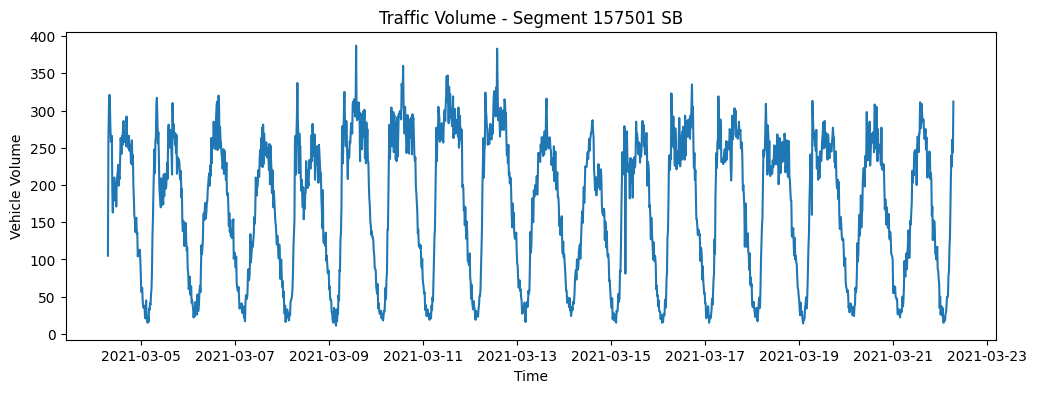

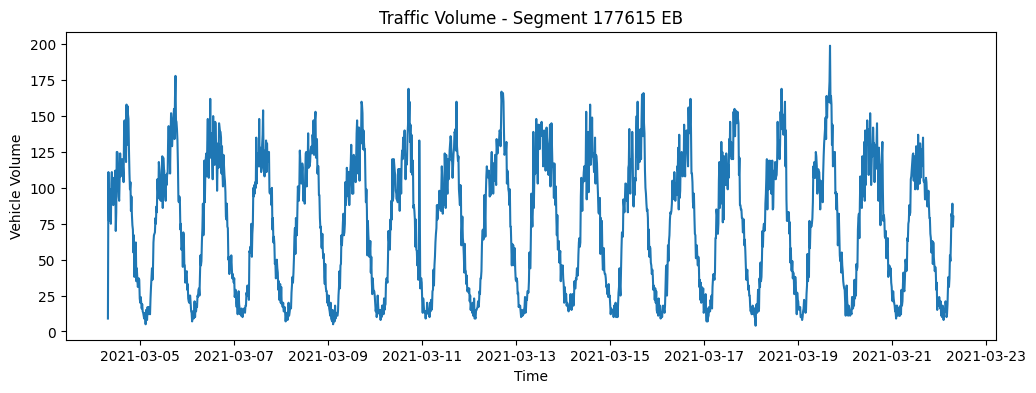

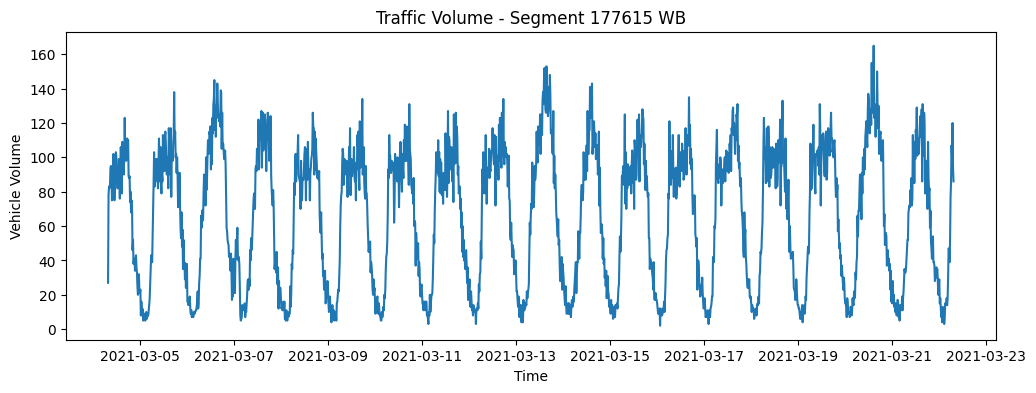

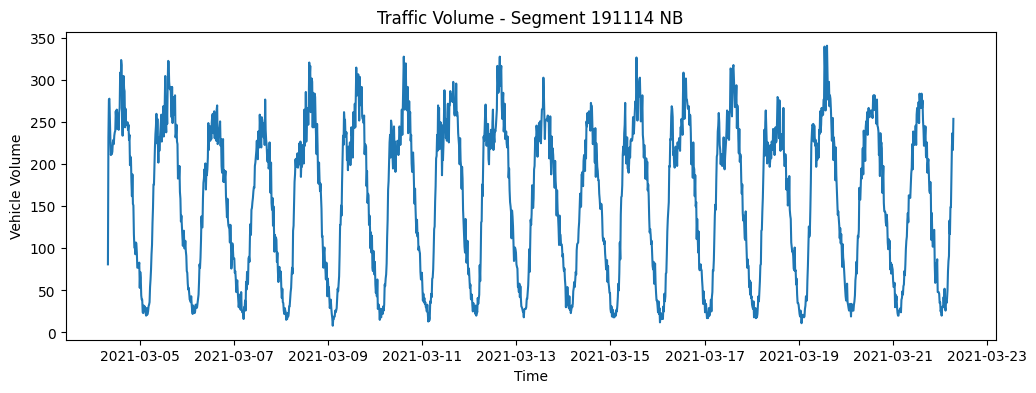

In [33]:
for (segment, direction), group in df.groupby(["SegmentID", "Direction"]):
    plt.figure(figsize=(12, 4))
    plt.plot(group["timestamp"], group["Vol"])
    plt.title(f"Traffic Volume - Segment {segment} {direction}")
    plt.xlabel("Time")
    plt.ylabel("Vehicle Volume")
    plt.show()

## 6. Traffic Volume by Time of Day

Hour of day is extracted from the timestamp and average traffic volume is calculated by hour. This helps identify recurring daily traffic patterns that may be useful for short-term forecasting.



### 6.1 Average Traffic Volume by Hour — Example Series

The current analysis visualizes the hourly pattern for Segment 157501 in the southbound (SB) direction.



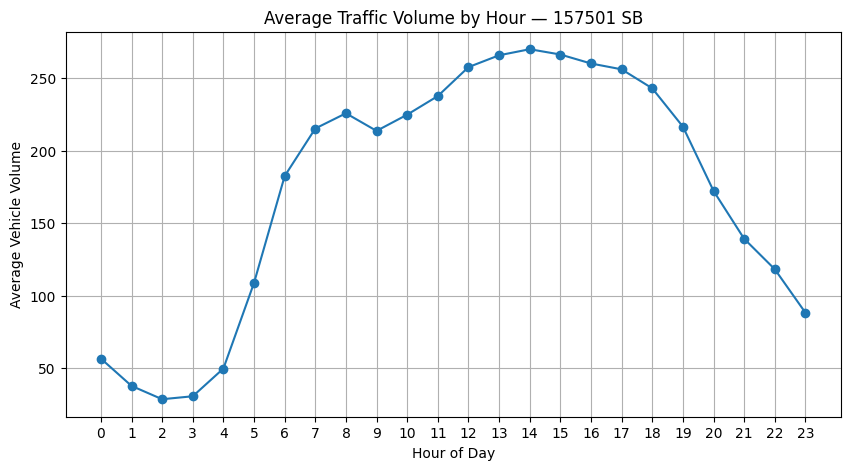

In [34]:
df["hour"] = df["timestamp"].dt.hour

hourly = (
    df.groupby(["SegmentID", "Direction", "hour"])["Vol"]
      .mean()
      .reset_index()
)

series = hourly[
    (hourly["SegmentID"] == 157501) &
    (hourly["Direction"] == "SB")
]

plt.figure(figsize=(10, 5))
plt.plot(series["hour"], series["Vol"], marker="o")
plt.xlabel("Hour of Day")
plt.ylabel("Average Vehicle Volume")
plt.title("Average Traffic Volume by Hour — 157501 SB")
plt.xticks(range(24))
plt.grid(True)
plt.show()

## 7. Traffic Volume by Day of Week

The day of the week is derived from the timestamp. Average traffic volume is then calculated separately for each SegmentID + Direction series and compared across Monday through Sunday.



### 7.1 Average Traffic Volume by Day of Week



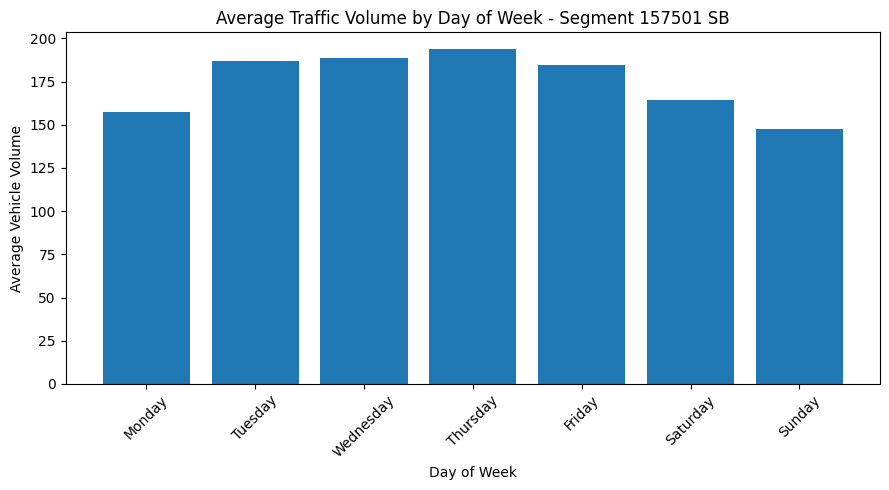

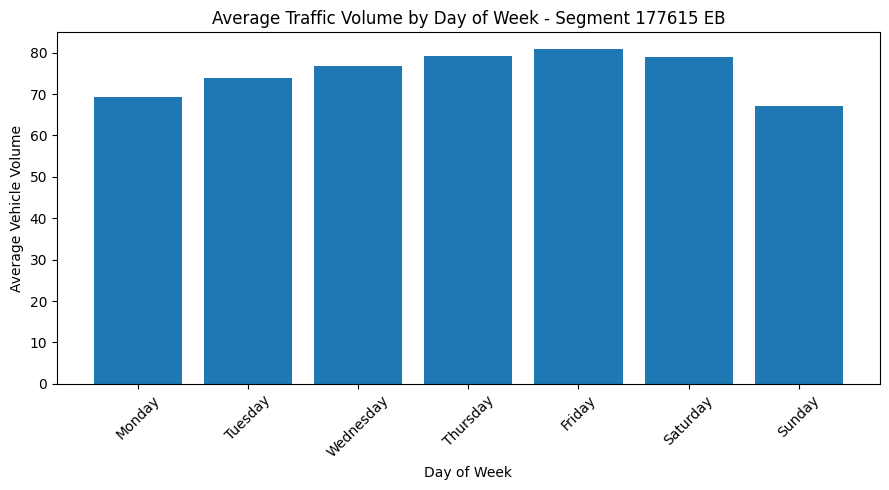

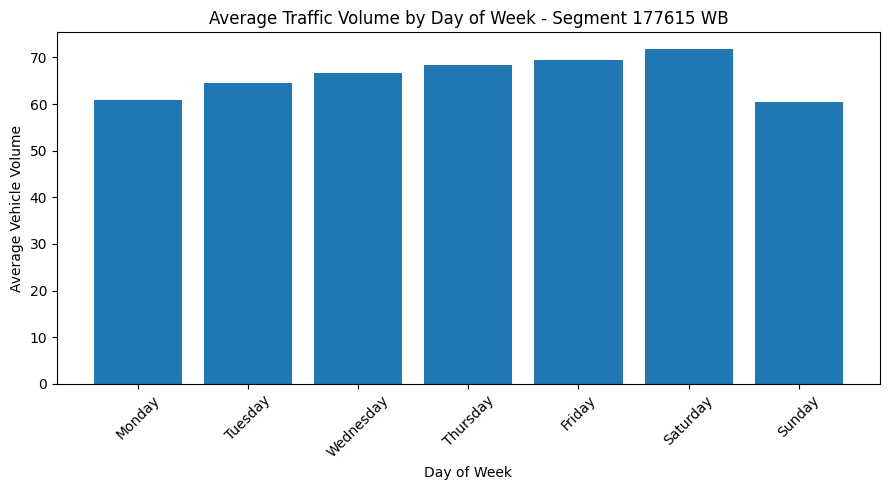

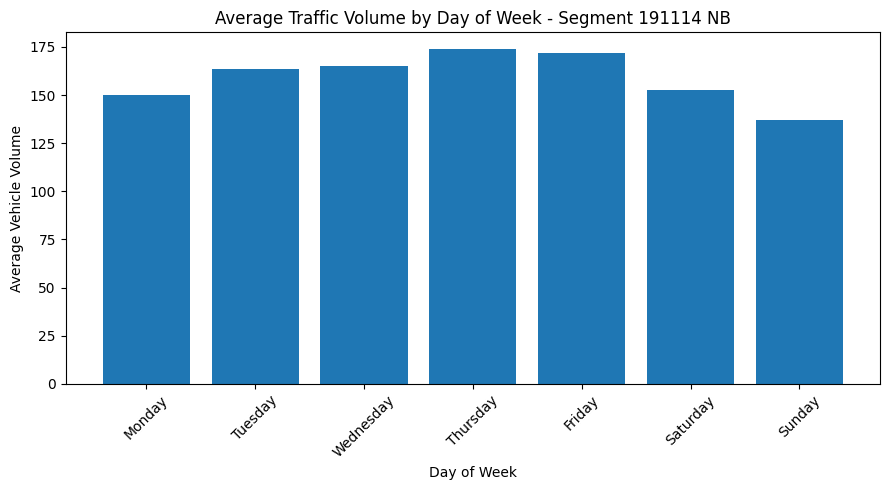

In [35]:
df["day_of_week"] = df["timestamp"].dt.day_name()

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

daily = (
    df.groupby(["SegmentID", "Direction", "day_of_week"])["Vol"]
      .mean()
      .reset_index()
)

daily["day_of_week"] = pd.Categorical(
    daily["day_of_week"],
    categories=day_order,
    ordered=True
)

daily = daily.sort_values("day_of_week")

# Plot average traffic volume by day of week
for (segment, direction), group in daily.groupby(
    ["SegmentID", "Direction"]
):

    plt.figure(figsize=(9, 5))

    plt.bar(
        group["day_of_week"],
        group["Vol"]
    )

    plt.title(
        f"Average Traffic Volume by Day of Week - "
        f"Segment {segment} {direction}"
    )

    plt.xlabel("Day of Week")
    plt.ylabel("Average Vehicle Volume")
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

## 8. Traffic Volume Summary Statistics

Summary statistics are calculated separately for each SegmentID + Direction series. These statistics show the number of observations, central tendency, variability, and minimum and maximum recorded volumes.



In [36]:
summary = (
    df.groupby(["SegmentID", "Direction"])["Vol"]
      .agg(["count", "mean", "median", "std", "min", "max"])
)

summary

count        mean  median        std  min  max
SegmentID Direction                                                
157501    SB          1728  173.621528   199.0  93.154020   11  387
177615    EB          1728   75.309028    79.0  45.524537    4  199
          WB          1727   66.209612    76.0  39.647594    2  165
191114    NB          1727  158.634627   179.0  90.179294    8  341

## 9. Traffic Volume Distribution

A histogram is used to examine the overall distribution of recorded vehicle volumes and to understand the range and frequency of traffic-volume observations.



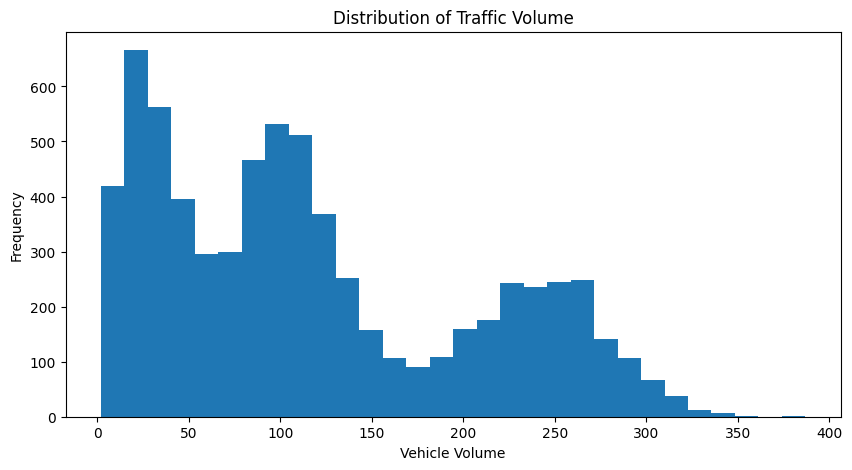

In [37]:
plt.figure(figsize=(10, 5))

plt.hist(df["Vol"], bins=30)

plt.xlabel("Vehicle Volume")
plt.ylabel("Frequency")
plt.title("Distribution of Traffic Volume")

plt.show()

## 10. Data Quality Checks

Before creating lag features, it is important to verify that observations are ordered correctly, occur at the expected 15-minute intervals, and do not contain duplicate timestamps within a forecasting series.



### 10.1 Missing Values

The following check identifies missing values in each column of the selected dataset.



In [27]:
# Check missing values in each column
df.isna().sum()


### 10.2 Timestamp Gaps and 15-Minute Intervals

The data is sorted by SegmentID, Direction, and timestamp. The difference between consecutive observations is then checked separately for each forecasting series.



In [38]:
df = df.sort_values(
    ["SegmentID", "Direction", "timestamp"]
)

df["time_diff"] = (
    df.groupby(["SegmentID", "Direction"])["timestamp"]
      .diff()
)

df["time_diff"].value_counts()

,count
time_diff,
0 days 00:15:00,6906


The interval check shows that the observed consecutive intervals are 15 minutes. The four series do not all contain the same number of observations, so the number of available records for each series should still be considered when creating forecasting features.



### 10.3 Duplicate Observations

Duplicate observations are checked using SegmentID, Direction, and timestamp. These three fields together identify a traffic observation within a forecasting series.



In [39]:
duplicates = df.duplicated(
    subset=["SegmentID", "Direction", "timestamp"]
)

duplicates.sum()

np.int64(0)

## 11. EDA Findings

The exploratory analysis provides the following observations:

- The selected dataset contains **6,910 observations** across four meaningful SegmentID + Direction series.
- The four forecasting series are **157501 SB, 177615 EB, 177615 WB, and 191114 NB**.
- Traffic volume differs substantially across the selected road-direction series.
- Traffic volume varies over time and across different hours of the day.
- Day-of-week analysis provides a way to examine differences between weekday and weekend traffic patterns.
- Consecutive observed timestamps occur at 15-minute intervals in the selected series.
- No duplicate observations were identified using SegmentID, Direction, and timestamp.
- The selected series do not all contain the same number of observations, so the forecasting pipeline should account for the available timestamps when creating lag features.

These findings describe the dataset only. They do not indicate which forecasting model will perform best; that will be determined later using held-out test data.



## 12. Implications for Forecasting

The findings from this phase will guide Phase 3, where the forecasting dataset is prepared.

In particular:

- Lag features should be created separately for each SegmentID + Direction series.
- The chronological order of observations must be preserved.
- The 15-minute time structure should be respected when creating lag features.
- Time-based variables such as hour and day of week can be used as candidate predictors.
- The target should represent vehicle volume **15 minutes into the future**.
- Training and testing must be separated chronologically to avoid using future observations to predict the past.



## 13. Phase 2 Summary

Phase 2 established an understanding of the selected traffic dataset and its main temporal patterns. The dataset has been inspected for structure and quality, and the traffic-volume behavior has been explored across time, hour of day, and day of week.

The next phase is to prepare the forecasting dataset by creating the target and lag-based features required for the machine-learning models.
